# Muon Train 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)

## Language Model

In [2]:
class RMSNorm(nn.Module):
    def __init__(self, dim, ):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(dim))
        self.epsilon = 1e-8
    def forward(self, X, ):
        bs, seq_len, dim = X.shape
        RMS = torch.rsqrt((X ** 2).mean(dim = -1, keepdim = True) + self.epsilon) # root-mean-square
        X_norm = X * RMS 
        Y = X_norm * self.gamma
        return Y
        
dim = 4
model = RMSNorm(dim)
X = torch.randn(2,3,4)
model(X)

class SwiGLU(nn.Module):
    def __init__(self, dim, ):
        super().__init__()
        self.dim = dim
        self.W_up = nn.Linear(self.dim, 4 * self.dim, bias = None)
        self.W_act = nn.Linear(self.dim, 4 * self.dim, bias = None)
        self.W_down = nn.Linear(4 * self.dim, self.dim, bias = None)
    def forward(self, X):
        bs, seq_len, dim = X.shape
        V = self.W_up(X)
        G = self.W_act(X)
        A = G * F.sigmoid(G)
        V = A * V
        Y = self.W_down(V)
        return Y
model = SwiGLU(dim)
model(X)

class Attention(nn.Module):
    def __init__(self, dim, heads = 8, ):
        super().__init__()
        self.dim = dim
        self.heads = heads
        self.head_dim = self.dim / self.heads
        
        # Attention, ignore RoPE
        self.Wq = nn.Linear(self.dim, self.dim, bias = None) 
        self.Wk = nn.Linear(self.dim, self.dim, bias = None)
        self.Wv = nn.Linear(self.dim, self.dim, bias = None)
        self.Wo = nn.Linear(self.dim, self.dim, bias = None)
        
    def forward(self, X):
        bs, seq_len, dim = X.shape
        Q, K, V = self.Wq(X), self.Wk(X), self.Wv(X)
        P = F.softmax(Q @ K.transpose(1,2), dim = -1)
        Z = P @ V
        O = self.Wo(Z)
        return O
model = Attention(dim, )
model(X)

tensor([[[-0.1858, -0.2819, -0.0030, -0.2152],
         [-0.2798, -0.0381, -0.2028, -0.3524],
         [-0.2750, -0.1706, -0.1233, -0.3320]],

        [[-0.1690,  0.2161, -0.1847, -0.2135],
         [ 0.0161,  0.3751, -0.0350, -0.0934],
         [-0.0691,  0.2954, -0.1047, -0.1456]]], grad_fn=<UnsafeViewBackward0>)

In [3]:
class DecoderBlocker(nn.Module):
    def __init__(self, dim, heads = 8, ):
        super().__init__()
        self.dim = dim
        self.heads = heads
        self.head_dim = self.dim / self.heads

        self.RMS_Norm_1 = RMSNorm(self.dim)
        self.Attn = Attention(self.dim)
        self.RMS_Norm_2 = RMSNorm(self.dim)
        self.SwiGLU = SwiGLU(self.dim)

    def forward(self, X, ): # ignore mask
        bs, seq_len, dim = X.shape
        X_ = self.RMS_Norm_1(X)
        X = self.Attn(X_) + X
        X_ = self.RMS_Norm_2(X)
        X = self.SwiGLU(X_) + X
        return X

model = DecoderBlocker(dim, )
model(X)

tensor([[[ 1.9411,  1.7890,  0.8378, -1.7935],
         [ 0.8298, -0.8938, -0.2452, -1.7199],
         [ 0.5144, -0.4357, -0.7711,  0.1862]],

        [[-1.4926,  0.2379, -1.9904,  0.0937],
         [-0.3753, -0.2440,  0.7640, -0.4977],
         [-0.9586,  0.0587, -0.6387,  0.6353]]], grad_fn=<AddBackward0>)

In [4]:
class LanguageModel(nn.Module):
    def __init__(self, 
                 dim, 
                 heads = 8, 
                 vocab_size = 100,
                 num_layers = 4):
        super().__init__()
        self.dim = dim
        self.embedding = nn.Embedding(vocab_size, dim)
        self.decoder = nn.ModuleList(
            [DecoderBlocker(dim, heads) for i in range(num_layers)]
        )
        self.RMS_Norm = RMSNorm(self.dim)
        self.LM_head = nn.Linear(dim, vocab_size, bias = None)
        
    def forward(self, input_ids):
        X = self.embedding(input_ids)

        for decode_block in self.decoder:
            X = decode_block(X)
            
        Y = self.RMS_Norm(X)
        logits = self.LM_head(Y)
        return logits

input_ids = torch.ones(2,3, dtype = torch.long)
model = LanguageModel(dim, )
logits = model(input_ids)
print(logits.shape)

torch.Size([2, 3, 100])


## Config

In [5]:
dim = 512 
vocab_size = 100
num_layers = 4
heads = 8

batch_size = 4
seq_len = 128

N = 2048 # dataset

## Dummy Dataset

pretrain dataset

In [6]:
X = torch.randint(2, vocab_size-1, (N, seq_len), dtype = torch.long) 
X[:, 0] = 0 # <SOS>
X[:, seq_len - 1] = 1 # <PAD> or <EOS>
print(X.shape)
print(X[0,:])

torch.Size([2048, 128])
tensor([ 0, 12, 13, 89, 81, 66, 36,  8, 60, 93, 82, 65, 38, 56, 21, 69, 68, 70,
        76, 74, 64, 66, 12, 74, 10, 89, 85, 59, 74, 17, 54, 95, 59, 72,  6, 67,
         9, 41, 21, 36, 18, 25, 91, 85, 53, 34, 54, 83, 63, 85, 77, 76,  7,  9,
        78,  9, 79, 31, 26,  5, 47, 50, 96, 60, 37, 66, 46, 37, 15, 77, 24, 46,
        62, 45, 40, 43, 86, 85, 50, 24, 37, 54, 50, 32, 53, 75,  3, 14, 17, 84,
        38, 49, 42, 33, 31, 59, 14, 53, 55, 39, 56, 16, 34, 60, 38, 56, 97, 49,
        73, 80,  4, 85, 63, 96, 53, 13, 67, 56, 52,  9, 28, 71, 82, 47, 79,  2,
        37,  1])


In [7]:
from torch.utils.data  import TensorDataset, DataLoader

train_dataset = TensorDataset(X)

def collate_fn(batch):

    batch = [ torch.unsqueeze(b[0], dim = 0) for b in batch ]

    input_ids = torch.concat(batch, dim = 0)
    label = torch.roll(input_ids, shifts = -1)
    label[:, -1] = -100 # ignore 
    
    return {'input_ids': input_ids, 'label': label}

train_dataloader = DataLoader(train_dataset, 
                    batch_size=batch_size, 
                    collate_fn=collate_fn,
                    pin_memory=True)

for batch in train_dataloader:
    print(batch['input_ids'][0])
    print(batch['label'][0])
    break

tensor([ 0, 12, 13, 89, 81, 66, 36,  8, 60, 93, 82, 65, 38, 56, 21, 69, 68, 70,
        76, 74, 64, 66, 12, 74, 10, 89, 85, 59, 74, 17, 54, 95, 59, 72,  6, 67,
         9, 41, 21, 36, 18, 25, 91, 85, 53, 34, 54, 83, 63, 85, 77, 76,  7,  9,
        78,  9, 79, 31, 26,  5, 47, 50, 96, 60, 37, 66, 46, 37, 15, 77, 24, 46,
        62, 45, 40, 43, 86, 85, 50, 24, 37, 54, 50, 32, 53, 75,  3, 14, 17, 84,
        38, 49, 42, 33, 31, 59, 14, 53, 55, 39, 56, 16, 34, 60, 38, 56, 97, 49,
        73, 80,  4, 85, 63, 96, 53, 13, 67, 56, 52,  9, 28, 71, 82, 47, 79,  2,
        37,  1])
tensor([  12,   13,   89,   81,   66,   36,    8,   60,   93,   82,   65,   38,
          56,   21,   69,   68,   70,   76,   74,   64,   66,   12,   74,   10,
          89,   85,   59,   74,   17,   54,   95,   59,   72,    6,   67,    9,
          41,   21,   36,   18,   25,   91,   85,   53,   34,   54,   83,   63,
          85,   77,   76,    7,    9,   78,    9,   79,   31,   26,    5,   47,
          50,   96,   6

## Optimizer

In [8]:
model.parameters

for name, param in model.named_parameters():
    print(name, param.shape, )
    # break

embedding.weight torch.Size([100, 4])
decoder.0.RMS_Norm_1.gamma torch.Size([4])
decoder.0.Attn.Wq.weight torch.Size([4, 4])
decoder.0.Attn.Wk.weight torch.Size([4, 4])
decoder.0.Attn.Wv.weight torch.Size([4, 4])
decoder.0.Attn.Wo.weight torch.Size([4, 4])
decoder.0.RMS_Norm_2.gamma torch.Size([4])
decoder.0.SwiGLU.W_up.weight torch.Size([16, 4])
decoder.0.SwiGLU.W_act.weight torch.Size([16, 4])
decoder.0.SwiGLU.W_down.weight torch.Size([4, 16])
decoder.1.RMS_Norm_1.gamma torch.Size([4])
decoder.1.Attn.Wq.weight torch.Size([4, 4])
decoder.1.Attn.Wk.weight torch.Size([4, 4])
decoder.1.Attn.Wv.weight torch.Size([4, 4])
decoder.1.Attn.Wo.weight torch.Size([4, 4])
decoder.1.RMS_Norm_2.gamma torch.Size([4])
decoder.1.SwiGLU.W_up.weight torch.Size([16, 4])
decoder.1.SwiGLU.W_act.weight torch.Size([16, 4])
decoder.1.SwiGLU.W_down.weight torch.Size([4, 16])
decoder.2.RMS_Norm_1.gamma torch.Size([4])
decoder.2.Attn.Wq.weight torch.Size([4, 4])
decoder.2.Attn.Wk.weight torch.Size([4, 4])
decoder

In [9]:
class Muon:
    """
    ref: https://github.com/KellerJordan/Muon/blob/master/muon.py
    矩阵可以用 Muon,
    对于 embedding, rmsnorm 处理方式? 
    """
    def __init__(self, named_parameters, 
                 lr=1e-3, momentum = 0.9,
                 ):
        self.named_parameters = named_parameters
        self.lr = lr
        self.t = 0
        # self.lambdas = lambdas
        self.momentum = momentum
        self.M = {}
        # self.momentum_buffer = {}
        for name, param in named_parameters: 
            self.M[name] = torch.zeros_like(param.data, dtype = torch.float32)
            # self.momentum_buffer[name] = torch.zeros_like(param.data dtype = torch.float32)} 

    def muon_iter(self, M, steps = 5):
        a = 3.4445
        b = -4.7750
        c = 2.0315
        X = M.bfloat16()
        for _ in range(steps):
            A = X @ X.mT
            B = b * A + c * A @ A # quintic computation strategy adapted from suggestion by @jxbz, @leloykun, and @YouJiacheng
            X = a * X + B @ X
        return X
    
    def muon_update(self, G, M, beta=0.95, ns_steps=5, nesterov=True):
        M = beta * M + (1 - beta) * G
        if nesterov:
            M_ = G * (1 - beta) + M * beta
        else:
            M_ = M
        
        dW = self.muon_iter(M_, steps=ns_steps)
        return dW

    def step(self,  weight_decay=1e-2):
        # a, b, c = self.lambdas
        for name, param in self.named_parameters: 
            if name in self.M:
                if param.grad is None:
                    param.grad = torch.zeros_like(p)
                
                G = param.grad
                M = self.M[name]

                dW = self.muon_update(G, M, beta = self.momentum)
                print(dW.shape)
                param = param * ( 1 - self.lr * weight_decay) # 权重衰减
                param = param - self.lr * dW # 更新
                
    def zero_grad(self, ):
        for name, param in self.named_parameters: 
            if name in self.M:
                if param.grad is None:
                    param.grad = torch.zeros_like(p)

In [10]:
model = Attention(dim, )
optimizer = Muon(model.named_parameters(), lr=1e-3)

X = torch.randn(2,3,dim)
Y = model(X)
loss = Y.sum()
loss.backward()
optimizer.step()
optimizer.zero_grad()

## Evaluate

In [11]:
def evaluate(data_loader, model):
    loss_fn = nn.CrossEntropyLoss(ignore_index = -100)
    PPL = 0
    loss_total = torch.zeros(1)
    t = 1
    with torch.no_grad():
        for batch in data_loader:
            X = batch['input_ids']
            label = batch['label']
            logits = model(X)
            
            bs, seq_len = X.shape
            loss = loss_fn(logits.view( bs*seq_len, vocab_size) , label.view( bs*seq_len) )
        
            loss_total = loss_total + loss.item()
            # PPL = PPL + torch.exp(-loss)
            t = t + 1
    loss_total = loss_total / t
    # PPL = PPL / t
    return loss_total, torch.exp(loss_total)

## Train

### dummy dataloader

In [12]:
# train_data
X = torch.randint(2, vocab_size-1, (N, seq_len), dtype = torch.long) 
X[:, 0] = 0 # <SOS>
X[:, seq_len - 1] = 1 # <PAD> or <EOS>
train_dataset = TensorDataset(X)
train_dataloader = DataLoader(train_dataset, 
                    batch_size = 8 , 
                    collate_fn=collate_fn,
                    pin_memory=True)

# evaluate_data
X = torch.randint(2, vocab_size-1, (N//8, seq_len), dtype = torch.long) 
X[:, 0] = 0 # <SOS>
X[:, seq_len - 1] = 1 # <PAD> or <EOS>
test_dataset = TensorDataset(X)
test_dataloader = DataLoader(test_dataset, 
                    batch_size= 32, 
                    collate_fn=collate_fn,
                    pin_memory=True)

In [13]:
len(train_dataloader)

256

In [14]:
model = LanguageModel(dim=dim, 
              heads=heads, 
              vocab_size = vocab_size, 
              num_layers = num_layers,)
                      
optimizer = Muon(model.named_parameters(), lr=1e-4)

loss_fn = nn.CrossEntropyLoss(ignore_index = -100)

epochs = 2
train_loss = []
test_loss = []
PPL = []
total_step = 0

# init evaluate
loss_tmp, PPL_tmp = evaluate(test_dataloader, model)
test_loss.append(loss_tmp.item())
PPL.append(PPL_tmp.item())
print(f"epochs:0, step:{total_step}, test_loss: {loss_tmp.item()}, PPL: {PPL_tmp.item()}")

# train
for i in range(epochs):
    # train
    for k, batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        X = batch['input_ids']
        label = batch['label']
        logits = model(X)
        
        bs, seq_len = X.shape
        loss = loss_fn(logits.view( bs*seq_len, vocab_size) , label.view( bs*seq_len) )
        
        train_loss.append(loss.item())
        loss.backward()
        optimizer.step()

        total_step = total_step + 1
        
        if total_step % 10 == 0: 
            print(f"epochs:{i}, step:{total_step}, train_loss: {loss.item()}")
    
    loss_tmp, PPL_tmp = evaluate(test_dataloader, model)
    test_loss.append(loss_tmp.item())
    PPL.append(PPL_tmp.item())
    print(f"epochs:{i}, step:{total_step}, train_loss: {loss.item()}, test_loss: {loss_tmp.item()}, PPL: {PPL_tmp.item()}")


epochs:0, step:0, test_loss: 4.240516662597656, PPL: 69.4437255859375
epochs:0, step:10, train_loss: 4.776068687438965
epochs:0, step:20, train_loss: 4.7666916847229
epochs:0, step:30, train_loss: 4.765238285064697
epochs:0, step:40, train_loss: 4.766195774078369
epochs:0, step:50, train_loss: 4.776840686798096
epochs:0, step:60, train_loss: 4.790563583374023
epochs:0, step:70, train_loss: 4.774212837219238
epochs:0, step:80, train_loss: 4.780297756195068
epochs:0, step:90, train_loss: 4.77052116394043
epochs:0, step:100, train_loss: 4.767505645751953
epochs:0, step:110, train_loss: 4.777315616607666
epochs:0, step:120, train_loss: 4.789003849029541
epochs:0, step:130, train_loss: 4.73935079574585
epochs:0, step:140, train_loss: 4.769733428955078
epochs:0, step:150, train_loss: 4.769815921783447
epochs:0, step:160, train_loss: 4.771607398986816
epochs:0, step:170, train_loss: 4.775240421295166
epochs:0, step:180, train_loss: 4.779141902923584
epochs:0, step:190, train_loss: 4.775910854

## Plot

[0, 256, 512]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 

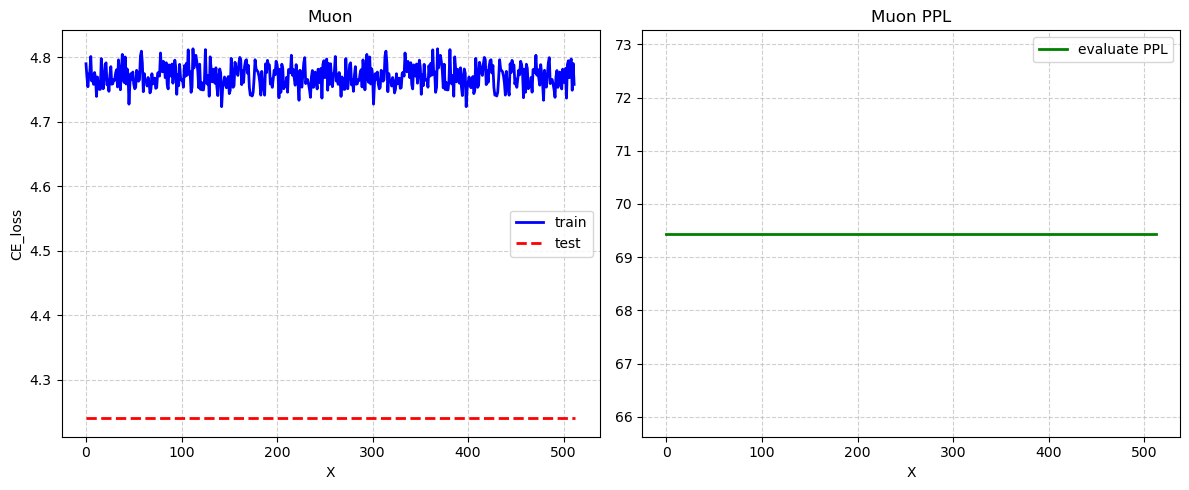

In [17]:
import matplotlib.pyplot as plt

# 创建数据
x = torch.arange(len(train_loss)).tolist()
x_test = (torch.arange(epochs+1) *(len(train_dataloader))).tolist()
print(x_test)
print(x)
y1 = train_loss
y2 = test_loss
y3 = PPL


# 创建1行2列的子图布局
plt.figure(figsize=(12, 5))  

# 第一个子图
plt.subplot(1, 2, 1)  # (行, 列, 位置)
plt.plot(x, y1, 'b-', linewidth=2, label='train')
plt.plot(x_test, y2, 'r--', linewidth=2, label='test')
plt.title('Muon')
plt.xlabel('X')
plt.ylabel('CE_loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 第二个子图
plt.subplot(1, 2, 2)
plt.plot(x_test, y3, 'g-', linewidth=2, label='evaluate PPL')
plt.title('Muon PPL')
plt.xlabel('X')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 自动调整子图间距
plt.tight_layout()

# 保存图片（可选）
# plt.savefig('dual_plot.png', dpi=300)

# 显示图形
plt.show()